# AKE Lab 1 · MLP für MNIST — Musterlösung

**Angewandte KI & KI-Engineering · Block A – Vertiefung Deep Learning · Woche 1**
Zugehöriges Skript: *Vom Perzeptron zum Deep Network*, Abschnitt 9 · Aufgabenblatt: `AKE_Lab01_Aufgabenblatt.pdf`

Musterlösung mit Referenzergebnissen. Die Zahlen stammen aus dem Lauf, mit dem dieses Notebook erzeugt wurde (`torch.manual_seed(0)`); auf anderer Hardware weichen Laufzeiten und Nachkommastellen ab, die qualitativen Aussagen nicht.

**Rechenbudget (Basis-Lab, Referenzhardware 4 Kerne / 8 GB, keine GPU):** reine Rechenzeit ≈ 8–12 Min. Alle
Experimente schreiben ihre Trainingslogs als JSON nach `results/`. Bricht ein eigener Lauf ab, können Sie die
mitgelieferten Referenzlogs aus `results_referenz/` laden und die Analyse trotzdem bearbeiten.


## 0 · Setup und Daten

Importe, Pfade, MNIST-Splits (54 000 / 6 000 / 10 000) wie in Skript Listing 3. Der Testsplit wird **ausschließlich** für die finale Bewertung je Aufgabe benutzt – nie zur Modellauswahl (Abschn. 6.1).

In [1]:
import os, time, json, math, copy
from pathlib import Path

import numpy as np
import torch, torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)

# MNIST liegt auf dem Hochschul-Share unter <Share>/data/MNIST. Ordner nach ./data kopieren
# (oder AKE_DATA auf den Share-Pfad setzen). Fehlt er, laedt torchvision die ~12 MB herunter.
DATA_ROOT = os.environ.get("AKE_DATA", "data")
RESULTS   = Path("results"); RESULTS.mkdir(exist_ok=True)   # Trainingslogs je Experiment (JSON)

print("torch", torch.__version__, "| Threads:", torch.get_num_threads(), "| CUDA:", torch.cuda.is_available())

torch 2.14.0+cu130 | Threads: 1 | CUDA: False


Train 54000 | Val 6000 | Test 10000 | Batches/Epoche: 844


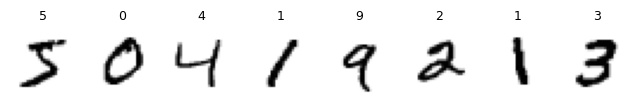

In [2]:
tf = transforms.Compose([transforms.ToTensor(),
                         transforms.Normalize((0.1307,), (0.3081,))])   # Mittelwert/Std von MNIST

full = datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=tf)
test = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=tf)
train, val = random_split(full, [54_000, 6_000], generator=torch.Generator().manual_seed(0))

def make_loaders(train_ds=train, batch_size=64):
    """Train-Loader wird gemischt, Val/Test nicht. Val/Test sind immer die vollen Splits."""
    return {"train": DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            "val":   DataLoader(val,      batch_size=256),
            "test":  DataLoader(test,     batch_size=256)}

dl = make_loaders()
print(f"Train {len(train)} | Val {len(val)} | Test {len(test)} | Batches/Epoche: {len(dl['train'])}")

fig, ax = plt.subplots(1, 8, figsize=(8, 1.4))
for i in range(8):
    x, y = full[i]
    ax[i].imshow(x[0], cmap="gray_r"); ax[i].set_title(y, fontsize=9); ax[i].axis("off")
plt.show()

### Modell, Trainings- und Evaluationsschleife

`MLP` verallgemeinert Listing 1 (variable Tiefe, Breite, Aktivierung, optional Dropout). `run_epoch`/`fit` sind die Referenzschleife aus Listing 3, ergänzt um Logging, Early Stopping und JSON-Export. Diese Schleife bleibt im Rest des Semesters praktisch unverändert (Abschn. 9.3).

In [3]:
class MLP(nn.Module):
    """MLP 784 -> hidden[0] -> ... -> n_classes. Ausgabe sind Logits (Softmax steckt im Loss).
    act: Aktivierungsklasse (nn.ReLU, nn.Sigmoid, ...); dropout: p nach jeder Aktivierung."""
    def __init__(self, d_in=784, hidden=(128, 128), n_classes=10, act=nn.ReLU, dropout=0.0, init="default"):
        super().__init__()
        layers, d = [nn.Flatten()], d_in
        for h in hidden:
            layers += [nn.Linear(d, h), act()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = h
        layers.append(nn.Linear(d, n_classes))                 # Logits, kein Softmax!
        self.net = nn.Sequential(*layers)
        self.reset_parameters(init)

    def reset_parameters(self, init):
        """init: "default" (PyTorch: kaiming_uniform mit a=sqrt(5), d.h. Var = 1/(3 n_in)),
        "glorot" (Var = 2/(n_in+n_out), Gl. 24) oder "he" (Var = 2/n_in, Gl. 25). Biases = 0."""
        if init == "default":
            return
        for m in self.net:
            if isinstance(m, nn.Linear):
                {"glorot": nn.init.xavier_normal_,
                 "he": lambda w: nn.init.kaiming_normal_(w, nonlinearity="relu")}[init](m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

model = MLP()
n_params = sum(p.numel() for p in model.parameters())
print(model.net)
print("Parameter:", n_params)   # Erwartung laut Skript (Bsp. 3.2): 785*128 + 129*128 + 129*10 = 118 282

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)
Parameter: 118282


In [4]:
lossf = nn.CrossEntropyLoss()   # erwartet Logits, kein Softmax davor!

def run_epoch(model, loader, opt=None):
    """Eine Epoche. opt=None => reine Evaluation (kein Gradient, eval()-Modus)."""
    train_mode = opt is not None
    model.train(train_mode)
    tot_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for x, y in loader:
            logits = model(x)
            loss = lossf(logits, y)
            if train_mode:
                opt.zero_grad(); loss.backward(); opt.step()
            tot_loss += loss.item() * len(y)
            correct  += (logits.argmax(1) == y).sum().item()
            n += len(y)
    return tot_loss / n, correct / n

def fit(model, opt, loaders, epochs, name=None, patience=None, verbose=True):
    """Trainiert `epochs` Epochen, loggt Train-/Val-Verlust und -Genauigkeit.
    patience=k: Early Stopping — Abbruch nach k Epochen ohne Verbesserung des Val-Verlusts,
    beste Parameter werden wiederhergestellt. Rueckgabe: history-Dict (auch als JSON in results/)."""
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    best_loss, best_state, bad = float("inf"), None, 0
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr = run_epoch(model, loaders["train"], opt)
        va = run_epoch(model, loaders["val"])
        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"], (*tr, *va)):
            hist[k].append(v)
        hist["epoch_time"].append(time.time() - t0)
        if verbose:
            print(f"  Epoche {ep:3d}: train loss {tr[0]:.4f} acc {tr[1]:.2%} | "
                  f"val loss {va[0]:.4f} acc {va[1]:.2%} | {hist['epoch_time'][-1]:.1f}s")
        if not math.isfinite(va[0]):
            print("  -> Verlust nicht endlich, Abbruch."); break
        if va[0] < best_loss:
            best_loss, bad = va[0], 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad += 1
            if patience is not None and bad >= patience:
                print(f"  -> Early Stopping nach Epoche {ep} (bestes Val-Loss {best_loss:.4f} "
                      f"in Epoche {ep - bad}).")
                break
    if patience is not None and best_state is not None:
        model.load_state_dict(best_state)          # Parameterstand am Val-Minimum behalten
    hist["best_epoch"] = int(np.argmin(hist["val_loss"])) + 1
    if name:
        (RESULTS / f"{name}.json").write_text(json.dumps(hist, indent=1))
    return hist

def plot_history(hists, title="", metric="loss", ax=None, logy=False):
    """hists: {label: history}. Zeichnet Train (durchgezogen) und Val (gestrichelt)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 3.6))
    for i, (label, h) in enumerate(hists.items()):
        c = f"C{i}"
        ax.plot(range(1, len(h[f"train_{metric}"]) + 1), h[f"train_{metric}"], c, label=f"{label} (train)")
        ax.plot(range(1, len(h[f"val_{metric}"]) + 1),   h[f"val_{metric}"],   c + "--", label=f"{label} (val)")
    ax.set_xlabel("Epoche"); ax.set_ylabel(metric); ax.set_title(title); ax.grid(alpha=.3)
    if logy: ax.set_yscale("log")
    ax.legend(fontsize=7)
    return ax

## Aufgabe 1 · Baseline

MLP 784–128–128–10 (ReLU), Adam $\alpha=10^{-3}$, Batch 64, 5 Epochen auf den vollen 54 000 Trainingsbildern. Erwartung: ≈ 97–98 % Testgenauigkeit. Vorher der erste Schritt des Debug-Protokolls (Abschn. 8): Verlust beim ersten Batch ≈ ln 10.

Verlust vor Training: 2.329  (erwartet ~ ln 10 = 2.303)


  Epoche   1: train loss 0.2700 acc 92.04% | val loss 0.1436 acc 95.40% | 7.4s


  Epoche   2: train loss 0.1123 acc 96.53% | val loss 0.0917 acc 96.90% | 6.7s


  Epoche   3: train loss 0.0796 acc 97.52% | val loss 0.0843 acc 97.38% | 7.1s


  Epoche   4: train loss 0.0595 acc 98.11% | val loss 0.1059 acc 96.42% | 7.1s


  Epoche   5: train loss 0.0493 acc 98.42% | val loss 0.0863 acc 97.47% | 6.9s



Test: loss 0.0935 | acc 97.17% | Gesamtzeit 36s


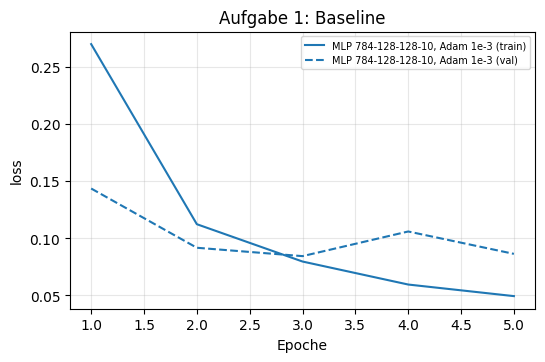

In [5]:
torch.manual_seed(0)
model = MLP(hidden=(128, 128))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Debug-Protokoll Schritt 1 (Skript Abschn. 8): Verlust vor dem Training ~ ln(10) = 2.303?
x0, y0 = next(iter(dl["train"]))
print(f"Verlust vor Training: {lossf(model(x0), y0).item():.3f}  (erwartet ~ ln 10 = {math.log(10):.3f})")

t0 = time.time()
h_base = fit(model, opt, dl, epochs=5, name="a1_baseline")
test_loss, test_acc = run_epoch(model, dl["test"])
print(f"\nTest: loss {test_loss:.4f} | acc {test_acc:.2%} | Gesamtzeit {time.time()-t0:.0f}s")
torch.save(model.state_dict(), RESULTS / "a1_baseline.pt")

plot_history({"MLP 784-128-128-10, Adam 1e-3": h_base}, "Aufgabe 1: Baseline")
plt.show()

In [6]:
# Zusatz: Wo irrt das Modell? Konfusionsmatrix auf dem Testsplit.
model.eval(); conf = torch.zeros(10, 10, dtype=torch.long)
with torch.no_grad():
    for x, y in dl["test"]:
        pred = model(x).argmax(1)
        for t, p in zip(y, pred):
            conf[t, p] += 1
off = conf.clone(); off.fill_diagonal_(0)
top = torch.topk(off.flatten(), 5).indices
print("Haeufigste Verwechslungen (wahr -> vorhergesagt: Anzahl):")
for idx in top:
    t, p = divmod(idx.item(), 10)
    print(f"  {t} -> {p}: {conf[t, p].item()}")
print("Genauigkeit je Klasse:", [f"{conf[c, c].item()/conf[c].sum().item():.1%}" for c in range(10)])

Haeufigste Verwechslungen (wahr -> vorhergesagt: Anzahl):
  3 -> 9: 35
  4 -> 9: 32
  7 -> 9: 20
  3 -> 8: 15
  7 -> 2: 9
Genauigkeit je Klasse: ['98.6%', '99.2%', '97.8%', '93.4%', '95.8%', '96.9%', '97.3%', '96.3%', '98.2%', '98.1%']


### Interpretation Aufgabe 1

* **Sanity-Check bestanden:** Der Verlust vor dem Training liegt bei 2,33 ≈ ln 10 = 2,30 (Debug-Protokoll Schritt 1, Skript Abschn. 8). Ein deutlich anderer Wert hätte auf einen Bug hingedeutet (Softmax vor `CrossEntropyLoss`, falsche Label-Codierung).
* **Verlauf „gesund“ mit beginnender Schere (Abb. 19, rechts/zweites Bild):** Der Trainingsverlust sinkt monoton (0,27 → 0,05), der Validierungsverlust erreicht in Epoche 3 sein Minimum (0,084) und pendelt danach (0,106 / 0,086). Ab Epoche 3 lernt das Modell also überwiegend Trainingsrauschen – längeres Training ohne Regularisierung bringt nichts mehr; der Ausreißer in Epoche 4 ist typisch für Adam mit konstanter Lernrate (kein Lernratenabfall, Abschn. 5.2).
* **Testgenauigkeit 97,2 %** entspricht der Erwartung aus Bsp. 3.2 (97,1 % nach 2 Epochen, Murphy 2022, Tab. 13.2). Die verbleibenden Fehler konzentrieren sich auf visuell ähnliche Paare: 3→9 (35×), 4→9 (32×), 7→9 (20×), 3→8 (15×); Klasse 3 ist mit 93,4 % die schwächste.
* **Kein Softmax in der Ausgabe:** `nn.CrossEntropyLoss` rechnet log-sum-exp intern numerisch stabil (Gl. 8); ein vorgeschaltetes Softmax würde die Logits sättigen und den Gradienten $\hat p - y$ (Gl. 14) verkleinern – das Training liefe, aber schlechter (Abschn. 3.4, „In der Praxis“).
* Ein MLP nutzt keine räumliche Nachbarschaft der Pixel (Abschn. 1.5) – genau hier setzt das Skript *CNNs & Computer Vision* an.


## Aufgabe 2 · Architektur und Vanishing Gradients

10-schichtiges Netz (10 × 100 Einheiten), einmal mit Sigmoid, einmal mit ReLU, SGD $\epsilon = 0{,}1$. Nach dem ersten Batch die Gradientennorm der ersten Schicht messen (`model.net[1].weight.grad.norm()`) und mit Gl. (29) erklären. Anschließend prüfen, ob die Netze überhaupt lernen.

Sigmoid : Verlust 2.554 | model.net[1].weight.grad.norm() = 4.03e-06 | ||dL/dz_1|| = 4.13e-07 | ||dL/dz_10|| = 1.64e-01 | Verhaeltnis z_1/z_10 = 2.51e-06
ReLU    : Verlust 2.304 | model.net[1].weight.grad.norm() = 1.30e-01 | ||dL/dz_1|| = 6.09e-03 | ||dL/dz_10|| = 1.61e-01 | Verhaeltnis z_1/z_10 = 3.79e-02


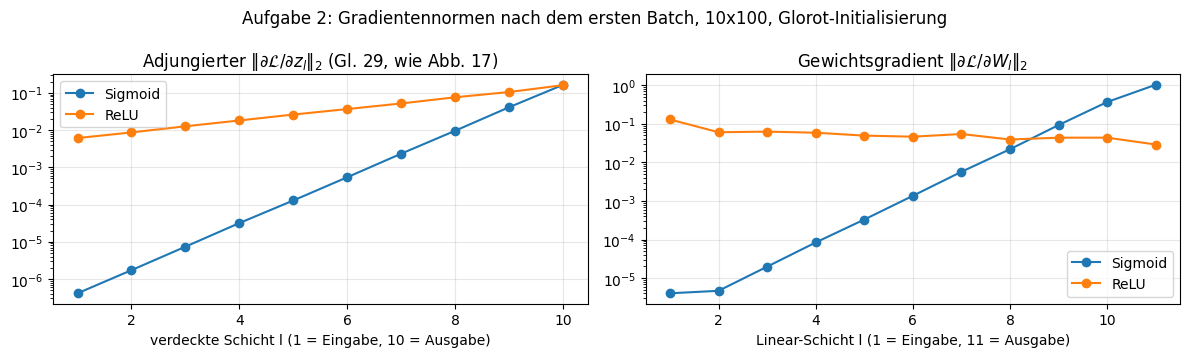

In [7]:
def grad_norms_first_batch(model, lr=0.1):
    """Vorwaerts- und Rueckwaertsdurchlauf auf dem ersten Batch (ohne Parameter-Update).
    Rueckgabe: (Loss, ||dL/dz_l|| je Aktivierung -- der Adjungierte aus Gl. 29, wie Abb. 17 --,
    ||dL/dW_l|| je Linear-Schicht)."""
    acts = []
    def keep(module, inp, out):          # Forward-Hook: Aktivierung merken und ihren Gradienten behalten
        out.retain_grad(); acts.append(out)
    hooks = [m.register_forward_hook(keep) for m in model.net if not isinstance(m, (nn.Linear, nn.Flatten))]
    x, y = next(iter(dl["train"]))
    model.zero_grad()
    loss = lossf(model(x), y)
    loss.backward()
    for h in hooks: h.remove()
    z_norms = [a.grad.norm().item() for a in acts]
    w_norms = [m.weight.grad.norm().item() for m in model.net if isinstance(m, nn.Linear)]
    return loss.item(), z_norms, w_norms

deep = {}
for act in (nn.Sigmoid, nn.ReLU):
    torch.manual_seed(0)
    m = MLP(hidden=(100,) * 10, act=act, init="glorot")        # 10 verdeckte Schichten a 100, Glorot wie Abb. 17
    loss0, zn, wn = grad_norms_first_batch(m)
    deep[act.__name__] = {"model": m, "z_norms": zn, "w_norms": wn, "loss0": loss0}
    print(f"{act.__name__:8s}: Verlust {loss0:.3f} | model.net[1].weight.grad.norm() = {wn[0]:.2e} | "
          f"||dL/dz_1|| = {zn[0]:.2e} | ||dL/dz_10|| = {zn[-1]:.2e} | Verhaeltnis z_1/z_10 = {zn[0]/zn[-1]:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for name, d in deep.items():
    axes[0].semilogy(range(1, 11), d["z_norms"], "o-", label=name)
    axes[1].semilogy(range(1, 12), d["w_norms"], "o-", label=name)
axes[0].set_title(r"Adjungierter $\|\partial\mathcal{L}/\partial z_l\|_2$ (Gl. 29, wie Abb. 17)")
axes[0].set_xlabel("verdeckte Schicht l (1 = Eingabe, 10 = Ausgabe)")
axes[1].set_title(r"Gewichtsgradient $\|\partial\mathcal{L}/\partial W_l\|_2$")
axes[1].set_xlabel("Linear-Schicht l (1 = Eingabe, 11 = Ausgabe)")
for ax in axes: ax.grid(alpha=.3); ax.legend()
fig.suptitle("Aufgabe 2: Gradientennormen nach dem ersten Batch, 10x100, Glorot-Initialisierung")
plt.tight_layout(); plt.show()
json.dump({k: {"z_norms": v["z_norms"], "w_norms": v["w_norms"]} for k, v in deep.items()},
          open(RESULTS / "a2_gradnorms.json", "w"), indent=1)

Sigmoid


  Epoche   1: train loss 2.3138 acc 11.08% | val loss 2.3511 acc 10.88% | 1.7s


  Epoche   2: train loss 2.3101 acc 11.04% | val loss 2.3549 acc 9.32% | 1.8s


  Epoche   3: train loss 2.3090 acc 10.59% | val loss 2.3333 acc 10.88% | 1.7s
ReLU


  Epoche   1: train loss 1.5968 acc 42.85% | val loss 0.7477 acc 76.10% | 1.8s


  Epoche   2: train loss 0.5466 acc 82.13% | val loss 0.3271 acc 90.68% | 1.9s


  Epoche   3: train loss 0.2778 acc 92.03% | val loss 0.3871 acc 88.97% | 1.8s


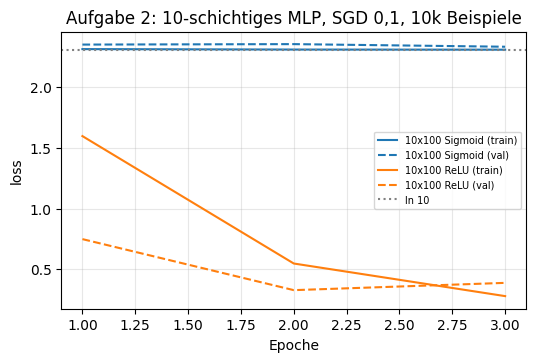

In [8]:
# Lernt das tiefe Netz ueberhaupt? 3 Epochen auf einem 10 000er-Subset, SGD lr=0.1 (klein, damit es schnell geht)
sub10k = Subset(train, range(10_000))
dl10k = make_loaders(sub10k)
h_deep = {}
for name, d in deep.items():
    print(name)
    opt = torch.optim.SGD(d["model"].parameters(), lr=0.1)
    h_deep[name] = fit(d["model"], opt, dl10k, epochs=3, name=f"a2_deep10_{name.lower()}")

plot_history({f"10x100 {k}": v for k, v in h_deep.items()}, "Aufgabe 2: 10-schichtiges MLP, SGD 0,1, 10k Beispiele")
plt.axhline(math.log(10), color="gray", ls=":", label="ln 10"); plt.legend(fontsize=7); plt.show()

In [9]:
# Zusatz: Rolle der Initialisierung (Skript Abschn. 5.6, Abb. 17). Gleiches ReLU-Netz, drei Initialisierungen,
# jeweils 3 Epochen SGD 0,1 auf dl10k. PyTorch-Default ist NICHT He: kaiming_uniform_(a=sqrt(5)) => Var = 1/(3 n_in).
h_init = {}
for init in ("default", "glorot", "he"):
    torch.manual_seed(0)
    m = MLP(hidden=(100,) * 10, act=nn.ReLU, init=init)
    _, zn, _ = grad_norms_first_batch(m)
    print(f"ReLU / {init:7s}: ||dL/dz_1|| = {zn[0]:.2e}, ||dL/dz_10|| = {zn[-1]:.2e}, Verhaeltnis = {zn[0]/zn[-1]:.2e}")
    h_init[init] = fit(m, torch.optim.SGD(m.parameters(), lr=0.1), dl10k, epochs=3, verbose=False,
                       name=f"a2_init_relu_{init}")
    print(f"           train loss nach 3 Ep.: {h_init[init]['train_loss'][-1]:.3f} | val acc {h_init[init]['val_acc'][-1]:.2%}")

# 30 Schichten wie in Abb. 17: nur die Gradientennorm, kein Training
for act, init in [(nn.Sigmoid, "glorot"), (nn.ReLU, "glorot"), (nn.ReLU, "he")]:
    torch.manual_seed(0)
    _, zn, _ = grad_norms_first_batch(MLP(hidden=(100,) * 30, act=act, init=init))
    print(f"30 Schichten {act.__name__:8s} {init:7s}: ||dL/dz_1|| / ||dL/dz_30|| = {zn[0]/zn[-1]:.2e}")

ReLU / default: ||dL/dz_1|| = 2.49e-05, ||dL/dz_10|| = 6.86e-02, Verhaeltnis = 3.63e-04


           train loss nach 3 Ep.: 2.301 | val acc 10.88%
ReLU / glorot : ||dL/dz_1|| = 6.09e-03, ||dL/dz_10|| = 1.61e-01, Verhaeltnis = 3.79e-02


           train loss nach 3 Ep.: 0.478 | val acc 86.35%
ReLU / he     : ||dL/dz_1|| = 1.52e-01, ||dL/dz_10|| = 1.74e-01, Verhaeltnis = 8.74e-01


           train loss nach 3 Ep.: 0.284 | val acc 84.18%
30 Schichten Sigmoid  glorot : ||dL/dz_1|| / ||dL/dz_30|| = 5.78e-19
30 Schichten ReLU     glorot : ||dL/dz_1|| / ||dL/dz_30|| = 5.19e-05
30 Schichten ReLU     he     : ||dL/dz_1|| / ||dL/dz_30|| = 1.14e+00


### Interpretation Aufgabe 2

* **Messung (Glorot-Initialisierung, erster Batch):** Sigmoid: $\|\partial\mathcal L/\partial z_1\| \approx 4\cdot 10^{-7}$ gegen $\approx 0{,}16$ an Schicht 10 – ein Verhältnis von $\approx 3\cdot 10^{-6}$ über 9 Schichten, also rund ein Faktor 4–5 pro Schicht. ReLU: Verhältnis $\approx 3\cdot 10^{-2}$, also nur Faktor ≈ 1,5 pro Schicht. Der Gewichtsgradient der ersten Schicht (`model.net[1].weight.grad.norm()`) liegt entsprechend bei $3\cdot 10^{-6}$ (Sigmoid) vs. $0{,}1$ (ReLU).
* **Erklärung mit Gl. (29):** Der Adjungierte an Schicht *l* ist ein Produkt $J_l^\top J_{l+1}^\top\cdots$ mit $J_l = \mathrm{diag}(\varphi'(a_{l+1}))\,W_{l+1}$. Bei Sigmoid ist $\varphi' \le 0{,}25$ (Tab. 2) – jede Schicht dämpft mindestens um den Faktor 4, das Signal verschwindet exponentiell mit der Tiefe. Bei ReLU ist $\varphi' \in \{0,1\}$: aktive Einheiten leiten ungedämpft weiter; der Restverlust (≈ 1/2 pro Schicht in der Varianz, Abb. 17) kommt daher, dass Glorot die „toten“ Hälften nicht kompensiert.
* **Trainingsverlauf:** Das Sigmoid-Netz bleibt bei 2,31 ≈ ln 10 und 10 % Genauigkeit – es rät (Tab. 5, Zeile 1: „Trainingsverlust sinkt nicht“; Ursache: Gradienten verschwinden). Die ersten Schichten erhalten praktisch kein Lernsignal, die Merkmalsextraktion findet nicht statt. Das ReLU-Netz lernt: Trainingsverlust 1,6 → 0,55 → 0,28, ≈ 92 % Trainings- und ≈ 89–91 % Validierungsgenauigkeit nach 3 Epochen auf 10 000 Bildern (SGD 0,1 ohne Momentum schwankt dabei sichtbar zwischen den Epochen).
* **Zusatzzelle – Initialisierung:** Mit PyTorch-Default (Var $=1/(3n_{\rm in})$, ein Sechstel von He) bleibt selbst das ReLU-Netz bei ln 10 hängen: Die Aktivierungen schrumpfen pro Schicht um den Faktor ≈ 1/6 in der Varianz, nach 10 Schichten sind die Logits ≈ 0 und der Gradient $\approx 2\cdot 10^{-5}$. He-Initialisierung hält das Verhältnis $\|\partial\mathcal L/\partial z_1\|/\|\partial\mathcal L/\partial z_{10}\| \approx 0{,}9$ und senkt den Trainingsverlust am schnellsten (0,28 nach 3 Epochen gegen 0,48 bei Glorot; die Validierungsgenauigkeit schwankt bei SGD 0,1 noch zu stark, um die beiden nach 3 Epochen zu trennen). Bei 30 Schichten wird der Unterschied drastisch: Glorot verliert 5 Größenordnungen, He hält das Verhältnis bei ≈ 1 – genau Abb. 17.
* **Gegenmaßnahmen (Abschn. 7.2)** greifen je an einem Faktor von Gl. (29) an: nicht sättigende Aktivierung → $\varphi'$; He-Initialisierung / Batch Norm → $\|W\|$ bzw. Aktivierungsstatistik; Residualverbindungen → machen die Struktur additiv statt multiplikativ (Gl. 30).


## Aufgabe 3 · Optimierer × Lernrate

SGD, SGD+Momentum (0,9) und Adam mit Lernraten $\{10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}\}$, je 2 Epochen. **Rechenbudget:** Der Sweep läuft auf dem 10 000er-Subset `dl10k` aus Aufgabe 2 (12 Läufe × 2 Epochen ≈ 2–3 Min. auf 4 Kernen); validiert wird auf dem vollen Validierungssplit. Welche Kombination erreicht den geringsten Validierungsverlust, welche divergiert?

In [10]:
OPTIMIZERS = {
    "SGD":          lambda p, lr: torch.optim.SGD(p, lr=lr),
    "SGD+Momentum": lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9),
    "Adam":         lambda p, lr: torch.optim.Adam(p, lr=lr),
}
LRS = [1e-4, 1e-3, 1e-2, 1e-1]

sweep = {}
t0 = time.time()
for oname, make_opt in OPTIMIZERS.items():
    for lr in LRS:
        torch.manual_seed(0)
        m = MLP(hidden=(128, 128))
        h = fit(m, make_opt(m.parameters(), lr), dl10k, epochs=2, verbose=False)
        sweep[(oname, lr)] = h
        vl, tl = h["val_loss"], h["train_loss"]
        flag = ("   <-- DIVERGIERT (Verlust > ln 10 = raten)" if not all(map(math.isfinite, tl + vl)) or max(tl) > math.log(10) + 0.5
                else "   <-- instabil (val loss steigt)" if vl[1] > vl[0]
                else "   <-- kaum Fortschritt (zu klein)" if h["val_acc"][-1] < 0.5 else "")
        print(f"{oname:13s} lr={lr:<6g}: val loss Ep.1/2 = {vl[0]:7.4f} / {vl[1]:7.4f} | val acc = {h['val_acc'][-1]:6.2%}{flag}")
print(f"Sweep-Zeit: {time.time()-t0:.0f}s")
json.dump({f"{o}|{lr}": h for (o, lr), h in sweep.items()}, open(RESULTS / "a3_sweep.json", "w"), indent=1)

best = min(sweep, key=lambda k: sweep[k]["val_loss"][-1] if math.isfinite(sweep[k]["val_loss"][-1]) else 1e9)
print("\nBeste Kombination:", best, f"-> val loss {sweep[best]['val_loss'][-1]:.4f}")

SGD           lr=0.0001: val loss Ep.1/2 =  2.3004 /  2.2958 | val acc = 10.37%   <-- kaum Fortschritt (zu klein)


SGD           lr=0.001 : val loss Ep.1/2 =  2.2603 /  2.2154 | val acc = 28.03%   <-- kaum Fortschritt (zu klein)


SGD           lr=0.01  : val loss Ep.1/2 =  1.4908 /  0.7092 | val acc = 81.23%


SGD           lr=0.1   : val loss Ep.1/2 =  0.3747 /  0.7333 | val acc = 78.10%   <-- instabil (val loss steigt)


SGD+Momentum  lr=0.0001: val loss Ep.1/2 =  2.2627 /  2.2187 | val acc = 26.92%   <-- kaum Fortschritt (zu klein)


...

SGD+Momentum  lr=0.1   : val loss Ep.1/2 =  0.3615 /  0.3302 | val acc = 91.07%


Adam          lr=0.0001: val loss Ep.1/2 =  0.7962 /  0.4620 | val acc = 88.08%


Adam          lr=0.001 : val loss Ep.1/2 =  0.3062 /  0.2444 | val acc = 92.60%


Adam          lr=0.01  : val loss Ep.1/2 =  0.2890 /  0.2996 | val acc = 90.80%   <-- instabil (val loss steigt)


Adam          lr=0.1   : val loss Ep.1/2 =  2.2019 /  2.1068 | val acc = 16.97%   <-- DIVERGIERT (Verlust > ln 10 = raten)
Sweep-Zeit: 39s

Beste Kombination: ('Adam', 0.001) -> val loss 0.2444


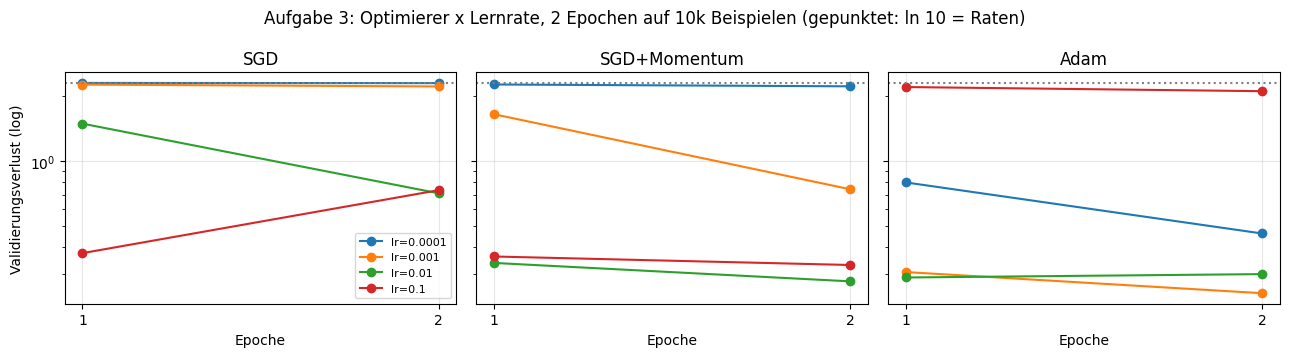

val loss         0.0001     0.001      0.01       0.1
SGD              2.2958    2.2154    0.7092    0.7333
SGD+Momentum     2.2187    0.7401    0.2773    0.3302
Adam             0.4620    0.2444    0.2996    2.1068


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, oname in zip(axes, OPTIMIZERS):
    for lr in LRS:
        h = sweep[(oname, lr)]
        ax.plot([1, 2], h["val_loss"], "o-", label=f"lr={lr:g}")
    ax.set_title(oname); ax.set_xlabel("Epoche"); ax.set_xticks([1, 2]); ax.grid(alpha=.3)
    ax.set_yscale("log"); ax.axhline(math.log(10), color="gray", ls=":")
axes[0].set_ylabel("Validierungsverlust (log)"); axes[0].legend(fontsize=8)
fig.suptitle("Aufgabe 3: Optimierer x Lernrate, 2 Epochen auf 10k Beispielen (gepunktet: ln 10 = Raten)")
plt.tight_layout(); plt.show()

# Ergebnismatrix
print(f"{'val loss':13s}" + "".join(f"{lr:>10g}" for lr in LRS))
for oname in OPTIMIZERS:
    print(f"{oname:13s}" + "".join(f"{sweep[(oname, lr)]['val_loss'][-1]:>10.4f}" for lr in LRS))

### Interpretation Aufgabe 3

* **Beste Kombination nach 2 Epochen:** Adam mit $\alpha = 10^{-3}$ (val loss 0,244, 92,6 %), dicht gefolgt von SGD+Momentum $10^{-2}$ (0,277) und Adam $10^{-2}$ (0,300 – hier steigt der Validierungsverlust von Epoche 1 zu 2 bereits leicht: erste Anzeichen für „zu groß“). Adam normiert jede Parameterrichtung einzeln mit bias-korrigierten Momenten (Abb. 13) und ist über zwei Zehnerpotenzen ($10^{-4}$…$10^{-2}$) brauchbar – der Grund für die Default-Empfehlung in Tab. 3 und die Startkonfiguration „Adam $10^{-3}$, dann $\{10^{-4},\dots,3\cdot 10^{-3}\}$ prüfen“.
* **Divergenz:** Adam $10^{-1}$ – Trainingsverlust 6,2 in Epoche 1, also weit über ln 10: Die Schrittweite ist die obere Schranke $\alpha$ pro Schritt im Parameterraum (Abschn. 5.5), $10^{-1}$ katapultiert die Gewichte in eine Region riesiger Logits; danach kollabiert das Modell auf Raten (17 %). Abb. 11: „viel zu groß“.
* **Instabil:** SGD $10^{-1}$ – Trainingsverlust sinkt (0,70 → 0,28), aber der Validierungsverlust springt von 0,38 auf 0,73 bei fallender Genauigkeit (89 → 78 %): Oszillation um das Minimum, das Rauschen dominiert (Abb. 11 „zu groß“, Tab. 5 Zeile 3). SGD+Momentum $10^{-1}$ hat effektive Schrittweite $\epsilon/(1-\alpha) = 1$ (Gl. 18) und ist ebenfalls am Rand: 0,36 → 0,33, schlechter als $10^{-2}$.
* **Zu klein:** SGD $10^{-4}$ und $10^{-3}$ kommen in zwei Epochen kaum vom Startwert weg (val loss 2,30 / 2,22, Abb. 11 „zu klein“). SGD ohne Momentum braucht hier rund eine Zehnerpotenz mehr Lernrate als SGD+Momentum, weil Momentum konsistente Gradientenkomponenten um $1/(1-\alpha)=10$ verstärkt (Abschn. 5.4).
* **Skalenbild:** SGD ist nur bei $10^{-2}$ gut, Momentum bei $10^{-2}$–$10^{-1}$, Adam bei $10^{-4}$–$10^{-2}$. Deshalb rastert man die Lernrate logarithmisch (Debug-Protokoll Schritt 3) und deshalb ist sie der wichtigste Hyperparameter (Abschn. 5.2). Ein Lauf pro Konfiguration ist außerdem nur eine Stichprobe – das erweiterte Lab (E2) wiederholt den Sweep über 3 Seeds.


## Aufgabe 4 · Regularisierungs-Ablation

Training auf nur 1 000 Beispielen (künstliche Datenknappheit), 50 Epochen, Adam $10^{-3}$. Vergleich: keine Regularisierung / Weight Decay $10^{-3}$ / Dropout 0,5 / Early Stopping (patience 5). Begründen Sie mit Tab. 4 des Skripts, welche Kombination Sie empfehlen. Die Testgenauigkeit wird je Variante genau einmal am Ende ermittelt.

In [12]:
sub1k = Subset(train, range(1_000))                # kuenstliche Datenknappheit
dl1k = make_loaders(sub1k)                          # 16 Batches/Epoche, Val/Test bleiben voll

VARIANTS = {
    "keine Regularisierung":   dict(dropout=0.0, weight_decay=0.0,  patience=None),
    "Weight Decay 1e-3":       dict(dropout=0.0, weight_decay=1e-3, patience=None),
    "Dropout 0,5":             dict(dropout=0.5, weight_decay=0.0,  patience=None),
    "Early Stopping (pat. 5)": dict(dropout=0.0, weight_decay=0.0,  patience=5),
    "Dropout + Early Stopping":dict(dropout=0.5, weight_decay=0.0,  patience=5),
}

reg = {}
for name, cfg in VARIANTS.items():
    torch.manual_seed(0)
    m = MLP(hidden=(128, 128), dropout=cfg["dropout"])
    # Adam(weight_decay=...) ist die gekoppelte L2-Variante (Skript Abschn. 6.2);
    # AdamW waere die entkoppelte -- Vergleich in der Zusatzzelle.
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=cfg["weight_decay"])
    print(name)
    h = fit(m, opt, dl1k, epochs=50, patience=cfg["patience"], verbose=False,
            name="a4_" + "".join(ch if ch.isalnum() else "_" for ch in name).lower())
    h["test_loss"], h["test_acc"] = run_epoch(m, dl["test"])
    reg[name] = h
    print(f"  Epochen {len(h['val_loss']):2d} | bestes val loss {min(h['val_loss']):.4f} (Ep. {h['best_epoch']}) | "
          f"letztes val loss {h['val_loss'][-1]:.4f} | train loss {h['train_loss'][-1]:.4f} | "
          f"Test acc {h['test_acc']:.2%}")

keine Regularisierung


  Epochen 50 | bestes val loss 0.3755 (Ep. 11) | letztes val loss 0.5087 | train loss 0.0008 | Test acc 89.65%
Weight Decay 1e-3


  Epochen 50 | bestes val loss 0.3704 (Ep. 11) | letztes val loss 0.4223 | train loss 0.0042 | Test acc 89.53%
Dropout 0,5


  Epochen 50 | bestes val loss 0.3660 (Ep. 19) | letztes val loss 0.4956 | train loss 0.0736 | Test acc 89.08%
Early Stopping (pat. 5)


  -> Early Stopping nach Epoche 16 (bestes Val-Loss 0.3755 in Epoche 11).


  Epochen 16 | bestes val loss 0.3755 (Ep. 11) | letztes val loss 0.3925 | train loss 0.0186 | Test acc 89.35%
Dropout + Early Stopping


  -> Early Stopping nach Epoche 24 (bestes Val-Loss 0.3660 in Epoche 19).


  Epochen 24 | bestes val loss 0.3660 (Ep. 19) | letztes val loss 0.3783 | train loss 0.1871 | Test acc 89.32%


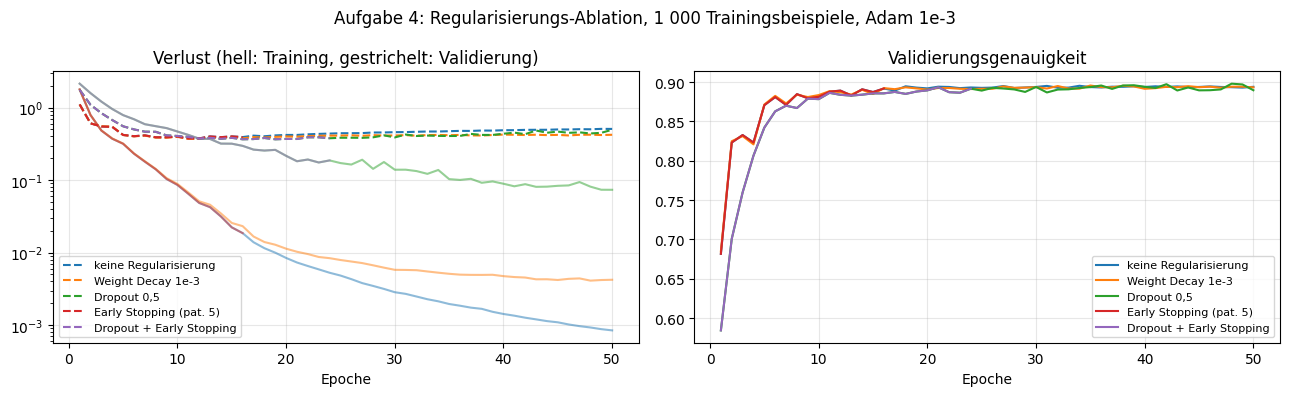

Variante                    Ep.  train loss  val loss (best)  val acc  test acc
keine Regularisierung        50      0.0008           0.3755   89.53%    89.65%
Weight Decay 1e-3            50      0.0042           0.3704   89.57%    89.53%
Dropout 0,5                  50      0.0736           0.3660   89.80%    89.08%
Early Stopping (pat. 5)      16      0.0186           0.3755   89.18%    89.35%
Dropout + Early Stopping     24      0.1871           0.3660   89.35%    89.32%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, (name, h) in enumerate(reg.items()):
    ep = range(1, len(h["val_loss"]) + 1)
    axes[0].plot(ep, h["train_loss"], f"C{i}", alpha=.5)
    axes[0].plot(ep, h["val_loss"],   f"C{i}--", label=name)
    axes[1].plot(ep, h["val_acc"],    f"C{i}", label=name)
axes[0].set_title("Verlust (hell: Training, gestrichelt: Validierung)"); axes[0].set_yscale("log")
axes[1].set_title("Validierungsgenauigkeit")
for ax in axes: ax.set_xlabel("Epoche"); ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.suptitle("Aufgabe 4: Regularisierungs-Ablation, 1 000 Trainingsbeispiele, Adam 1e-3")
plt.tight_layout(); plt.show()

print(f"{'Variante':26s} {'Ep.':>4s} {'train loss':>11s} {'val loss (best)':>16s} {'val acc':>8s} {'test acc':>9s}")
for name, h in reg.items():
    print(f"{name:26s} {len(h['val_loss']):4d} {h['train_loss'][-1]:11.4f} {min(h['val_loss']):16.4f} "
          f"{max(h['val_acc']):8.2%} {h['test_acc']:9.2%}")

In [14]:
# Zusatz: Wie stark muss Weight Decay sein, damit es bei 1 000 Beispielen sichtbar wirkt? Gekoppelt (Adam) vs. entkoppelt (AdamW).
extra = {}
for label, make in [("Adam wd=1e-2 (gekoppelt)",  lambda p: torch.optim.Adam(p,  lr=1e-3, weight_decay=1e-2)),
                    ("AdamW wd=1e-1 (entkoppelt)", lambda p: torch.optim.AdamW(p, lr=1e-3, weight_decay=1e-1)),
                    ("AdamW wd=1   (entkoppelt)",  lambda p: torch.optim.AdamW(p, lr=1e-3, weight_decay=1.0))]:
    torch.manual_seed(0)
    m = MLP(hidden=(128, 128))
    h = fit(m, make(m.parameters()), dl1k, epochs=50, verbose=False)
    h["test_loss"], h["test_acc"] = run_epoch(m, dl["test"])
    extra[label] = h
    print(f"{label:28s}: bestes val loss {min(h['val_loss']):.4f} | letztes {h['val_loss'][-1]:.4f} | Test acc {h['test_acc']:.2%}")

Adam wd=1e-2 (gekoppelt)    : bestes val loss 0.3502 | letztes 0.3661 | Test acc 89.60%


AdamW wd=1e-1 (entkoppelt)  : bestes val loss 0.3723 | letztes 0.4623 | Test acc 89.76%


AdamW wd=1   (entkoppelt)   : bestes val loss 0.3499 | letztes 0.3589 | Test acc 89.96%


### Interpretation Aufgabe 4

* **Schere ohne Regularisierung (Abb. 14):** Der Trainingsverlust geht auf 0,0008 – das Netz mit 118 282 Parametern lernt die 1 000 Bilder auswendig. Der Validierungsverlust erreicht in Epoche 11 sein Minimum (0,376) und steigt bis Epoche 50 auf 0,51. Die Validierungs**genauigkeit** bleibt dabei bei ≈ 89,5 %: Das Modell wird nicht falscher, sondern überkonfident bei den wenigen Fehlern – Cross-Entropy bestraft eine sichere Fehlklassifikation mit $-\log \hat p \to \infty$ (Tab. 5, letzte Zeile).
* **Testgenauigkeit ist hier das falsche Kriterium:** Alle Varianten liegen zwischen 89,1 und 89,7 % – innerhalb des Seed-Rauschens. Der Effekt der Regularisierung zeigt sich im Validierungs*verlust*, d. h. in der Kalibrierung der Wahrscheinlichkeiten; das ist relevant, sobald das Modell Konfidenzen liefern muss (Monitoring, Drift-Detection in Block C).
* **Weight Decay $10^{-3}$ (gekoppelt, Adam):** kleiner Effekt (letztes val loss 0,42 statt 0,51). Bei adaptiven Optimierern wird der Term $\lambda w$ mit $1/\sqrt{\hat v}$ skaliert (Abschn. 6.2), und $10^{-3}$ ist der untere Rand von Tab. 4. Zusatzzelle: Adam $\lambda = 10^{-2}$ (gekoppelt) und AdamW $\lambda = 1$ (entkoppelt) halten den Validierungsverlust bei 0,36 bzw. 0,35 – die beste Kalibrierung aller Läufe; AdamW mit $\lambda = 10^{-1}$ reicht noch nicht. Bei AdamW ist $\lambda$ auf einer anderen Skala als bei SGD, weil es multiplikativ mit $\epsilon\lambda$ pro Schritt wirkt.
* **Dropout 0,5:** verlangsamt das Auswendiglernen (Trainingsverlust 0,07 statt 0,0008), senkt den besten Validierungsverlust auf 0,366 (Epoche 19), überfittet aber nach 50 Epochen ebenfalls (0,50) – Dropout ersetzt Early Stopping nicht. Da Dropout im `eval()`-Modus aus ist, liegt der Validierungsverlust zeitweise *unter* dem Trainingsverlust – Tab. 5: normal, kein Handlungsbedarf.
* **Early Stopping:** kostet nichts (Tab. 4: „immer; erste Maßnahme“), bricht nach 16 Epochen ab, liefert den Parameterstand von Epoche 11 (val loss 0,376) – gleiche Genauigkeit wie 50 Epochen ohne Regularisierung, aber ein kalibriertes Modell in einem Drittel der Zeit. Für ein quadratisches Modell entspricht das $L^2$-Regularisierung mit $\lambda \approx 1/(\tau\epsilon)$ (Abschn. 6.3).
* **Empfehlung nach Tab. 4 (Reihenfolge in der Praxis):** Early Stopping → Weight Decay (bei Adam: AdamW mit $\lambda \approx 1$ oder gekoppelt $10^{-2}$) → Datenaugmentation (bei Ziffern erlaubt: kleine Verschiebung/Rotation, keine Spiegelung, Abschn. 6.5) → Dropout. Konkret: AdamW $\lambda = 1$ + Early Stopping. Der größte Hebel bei 1 000 Beispielen bleibt aber mehr Daten – „der beste Regularisierer“ (Abschn. 6.5).


## Aufgabe 5 (optional) · Backpropagation in NumPy

Implementieren Sie den Rückwärtsdurchlauf für das einschichtige MLP aus Bsp. 4.1 des Skripts (ReLU + Softmax/Cross-Entropy) und verifizieren Sie die Gradienten per zentraler finiter Differenzen auf einem winzigen Netz in `float64`.

In [15]:
def relu(z):  return np.maximum(z, 0)

def forward_np(params, X, y):
    """Einschichtiges MLP (Skript Bsp. 4.1): z = W x + b1, h = ReLU(z), a = V h + b2, L = mittlere CE.
    X: (N, D), y: (N,) int. Rueckgabe: Loss und Cache fuer den Rueckwaertsdurchlauf."""
    W, b1, V, b2 = params["W"], params["b1"], params["V"], params["b2"]
    Z = X @ W.T + b1                     # (N, K)
    H = relu(Z)                          # (N, K)
    A = H @ V.T + b2                     # (N, C) Logits
    A_shift = A - A.max(1, keepdims=True)                      # numerisch stabile Softmax
    logp = A_shift - np.log(np.exp(A_shift).sum(1, keepdims=True))
    loss = -logp[np.arange(len(y)), y].mean()
    return loss, dict(X=X, Z=Z, H=H, P=np.exp(logp), y=y)

def backward_np(params, cache):
    """Adjungierte von hinten nach vorne (Gl. 13-15, Bsp. 4.1). Mittelung ueber den Batch wie im Loss."""
    X, Z, H, P, y = cache["X"], cache["Z"], cache["H"], cache["P"], cache["y"]
    N = len(y)
    U2 = P.copy(); U2[np.arange(N), y] -= 1; U2 /= N            # dL/da = (p_hat - y)/N   (Gl. 14)
    grads = {"V": U2.T @ H, "b2": U2.sum(0)}                    # dL/dV = u2 h^T          (Gl. 15)
    U1 = (U2 @ params["V"]) * (Z > 0)                           # u1 = (V^T u2) o H(z)    (ReLU-VJP)
    grads["W"], grads["b1"] = U1.T @ X, U1.sum(0)               # dL/dW = u1 x^T
    return grads

def finite_diff(params, X, y, eps=1e-5):
    """Zentrale Differenzen fuer jeden Parameter -- nur fuer winzige Netze bezahlbar."""
    num = {}
    for k, p in params.items():
        g = np.zeros_like(p)
        for idx in np.ndindex(p.shape):
            old = p[idx]
            p[idx] = old + eps; lp, _ = forward_np(params, X, y)
            p[idx] = old - eps; lm, _ = forward_np(params, X, y)
            p[idx] = old
            g[idx] = (lp - lm) / (2 * eps)
        num[k] = g
    return num

# Winziges Netz in float64: D=5 Eingaben, K=4 verdeckte Einheiten, C=3 Klassen, N=7 Beispiele
rng = np.random.default_rng(0)
D, K, C, N = 5, 4, 3, 7
params = {"W": rng.normal(0, 1/np.sqrt(D), (K, D)), "b1": rng.normal(0, .1, K),
          "V": rng.normal(0, 1/np.sqrt(K), (C, K)), "b2": rng.normal(0, .1, C)}
X = rng.normal(size=(N, D)); y = rng.integers(0, C, N)

loss, cache = forward_np(params, X, y)
ana = backward_np(params, cache)
num = finite_diff(params, X, y)
print(f"Loss = {loss:.5f}")
for k in params:
    rel = np.abs(ana[k] - num[k]).max() / (np.abs(num[k]).max() + 1e-12)
    print(f"  {k:3s}: max |analytisch - numerisch| = {np.abs(ana[k]-num[k]).max():.2e}  (relativ {rel:.2e})")

# Gegenprobe mit torch.autograd
tp = {k: torch.tensor(v, requires_grad=True) for k, v in params.items()}
Xt, yt = torch.tensor(X), torch.tensor(y)
Lt = nn.functional.cross_entropy(torch.relu(Xt @ tp["W"].T + tp["b1"]) @ tp["V"].T + tp["b2"], yt)
Lt.backward()
print("Max. Abweichung zu torch.autograd:",
      max(np.abs(tp[k].grad.numpy() - ana[k]).max() for k in params))

Loss = 1.10438
  W  : max |analytisch - numerisch| = 1.40e-11  (relativ 7.27e-11)
  b1 : max |analytisch - numerisch| = 8.23e-12  (relativ 9.10e-11)
  V  : max |analytisch - numerisch| = 9.76e-12  (relativ 6.20e-11)
  b2 : max |analytisch - numerisch| = 1.20e-11  (relativ 3.99e-11)
Max. Abweichung zu torch.autograd: 5.551115123125783e-17


### Interpretation Aufgabe 5 (optional)

* Alle vier Gradienten stimmen bis auf $\approx 10^{-11}$ (relativ $\approx 10^{-10}$) mit den zentralen Differenzen überein und bis auf Maschinengenauigkeit ($5\cdot 10^{-17}$) mit `torch.autograd` – die Formeln aus Bsp. 4.1 sind korrekt implementiert. Der Rest zu den finiten Differenzen ist der Diskretisierungsfehler $O(\varepsilon^2)$.
* Der ganze Rückwärtsdurchlauf besteht aus einer Subtraktion ($\hat p - y$, Gl. 14), zwei Matrixprodukten mit Transponierten (die äußeren Produkte $u x^\top$ aus Gl. 15 als Batch-Version), einer Maske ($\mathbb 1[z>0]$, ReLU-VJP) und zwei Spaltensummen (Bias-Gradienten) – „Kosten ≈ 2× Vorwärtsdurchlauf“ (Abschn. 4.4.1).
* Finite Differenzen brauchen 2 Vorwärtsdurchläufe **pro Parameter**: hier $2\cdot 47 = 94$, für das Baseline-MLP wären es $2\cdot 118\,282$ – genau der Unterschied zwischen Vorwärts- (n Durchläufe) und Rückwärtsmodus (1 Durchlauf) aus Abschn. 4.3. Nützlich sind finite Differenzen nur als Test einer handgeschriebenen Backprop-Implementierung.


## Abgabe-Checkliste

- [ ] Notebook läuft mit *Kernel → Restart & Run All* fehlerfrei durch (oder: abgebrochene Läufe sind markiert und durch Referenzlogs ersetzt)
- [ ] Zu jeder Aufgabe: Kurven **und** Interpretation mit Skript-Bezug
- [ ] `results/` mit den JSON-Logs liegt bei (Seed, Konfiguration, Kurven – Abschn. 8: *Loggen Sie jeden Lauf*)
- [ ] Dateiname `lab01_<nachname>.ipynb`, Abgabe laut Aufgabenblatt